**Exercise and Lab: Pulse Shape Discrimination**

The goal of this exercise is to perform a pulse shape analysis on real data.

A scintillation detector is exposed to both neutron and gamma radiation, both emitted from a source places some half meter away from the detector. A detected particle (neutron or gamma) will result in an electrical pulse (a short signal) from the detector. However, the pulse shape of the detector signal depends looks different for both types of particles.

Together with the detector pulse, the flight time of the particle from the source to the detector is measured. (More on this in the introductory video for the lab.) Since gammas move at speed of light and neutrons don't, the flight times provide a second way of discriminating between neutrons and gammas, independent of the pulse shapes. Use this information to label the data.

We start by downloading a data file. For testing there is a small data set, once everything works, there is more data...

In [255]:
# # load data
# # The code snippet below is responsible for downloading the dataset
# # - for example when running via Google Colab.
# # It is enough to load one of the files below.

# # Small data file.
# import os
# if not os.path.exists("data_small.npy"):
#   !gdown https://drive.google.com/uc?id=1Ejrt2O6rRj0N7F29pXxsa-gELsVaGhfA

# # The small data file is enough to do this exercise but if you want you can also use much more data.
# # Large data file. Uncomment this line only if you really want to use all data.
# # !gdown https://drive.google.com/uc?id=1AcMxtW3GFsKpkLqDLwlDxgYFtbtzcrZQ

The next step will be do load the data into a numpy array and check it, e.g. by looking at some pulses.

The data consists of a (high) number of lines, each line representing one pulse.

In [256]:
import numpy as np
import matplotlib.pyplot as plt

data_raw = np.load('../datasets/neutron-gamma/data_small.npy')

# Check the size of the data file
print(data_raw.shape)
# Print the first pulse
# print(data[0])

(55686, 514)


### Data labelling and scaling

The first number in each line is a detector identifier, which we can happily ignore here.

The second number is the flight time in nanoseconds, this provides information about the particle type, neutron or gamma.

The pulse is sampled at a rate of 1 GHz, so the remaining 512 numbers represent 512 ns of the pulse shape.

(55686, 512)


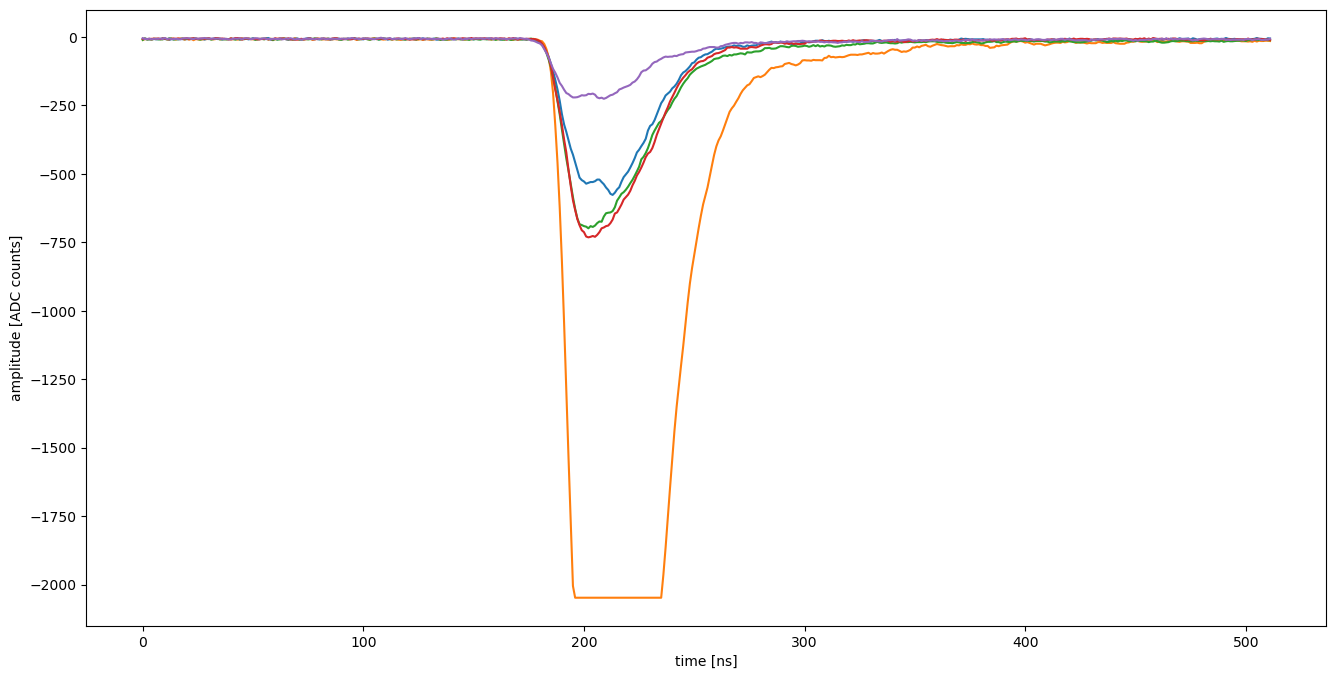

In [257]:
# Select only the pulse shape part of the data
pulses = data_raw[:,2:]
# Prepare a figure and plot some pulses
print(pulses.shape)
fig, ax = plt.subplots(figsize=(16,8))
ax.plot(pulses[0])
ax.plot(pulses[10])
ax.plot(pulses[100])
ax.plot(pulses[1000])
ax.plot(pulses[10000])
ax.set_xlabel("time [ns]")
ax.set_ylabel("amplitude [ADC counts]")
plt.show()

We will now extract the flight times.

In [258]:
times = data_raw[:,1]
print('Flight times between', times.min(), 'and', times.max(), 'nanoseconds.')

Flight times between -371.822 and 287.852 nanoseconds.


Negative flight times (also called times of flight, tof) are okay (for random coincidences), but we will restrict their range before plotting:

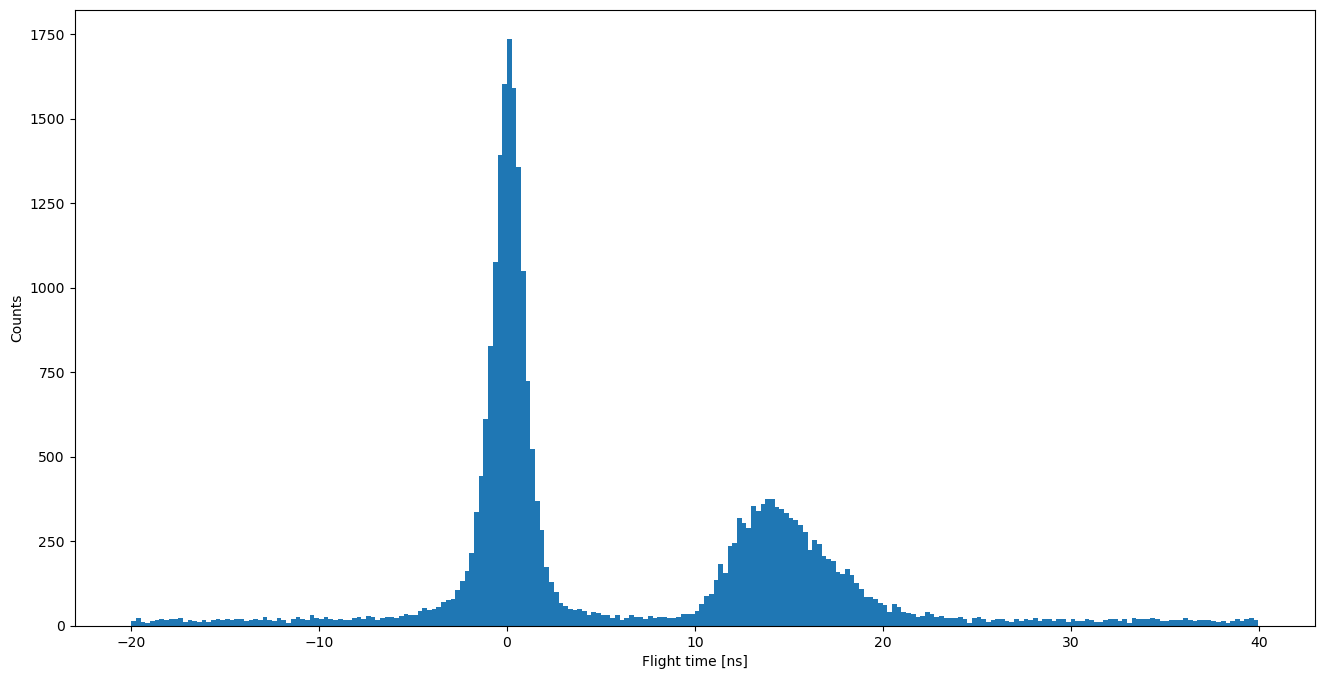

In [259]:
min_tof = -20
max_tof = 40
times = times[(times>=min_tof) & (times<=max_tof)]
# Now create a figure
fig, ax  = plt.subplots(figsize=(16,8))
ax.hist(times, bins=240)   # high resolution: 4 bins per nanosecond
ax.set_xlabel('Flight time [ns]')
ax.set_ylabel('Counts')
plt.show()

The flight time spectrum shows a gamma peak at around 0 ns and a neutron peak at around 10 to 20 ns.
You can now define flight time ranges within which you will accept gammas and neutrons. Please adjust the numbers below according to your data and your liking.
During the exercise class, we will discuss how the choice of the limits affects your results.

In [260]:
gamma_min_tof = -5
gamma_max_tof = 5
neutron_min_tof = 5
neutron_max_tof = 25

gammadata = data_raw[(data_raw[:,1] >= gamma_min_tof) & (data_raw[:,1] <= gamma_max_tof)]
gammapulses = gammadata[:,2:]
print('Gammas:  ', gammapulses.shape)

neutrondata = data_raw[(data_raw[:,1] >= neutron_min_tof) & (data_raw[:,1] <= neutron_max_tof)]
neutronpulses = neutrondata[:,2:]
print('Neutrons:', neutronpulses.shape)

Gammas:   (15870, 512)
Neutrons: (9910, 512)


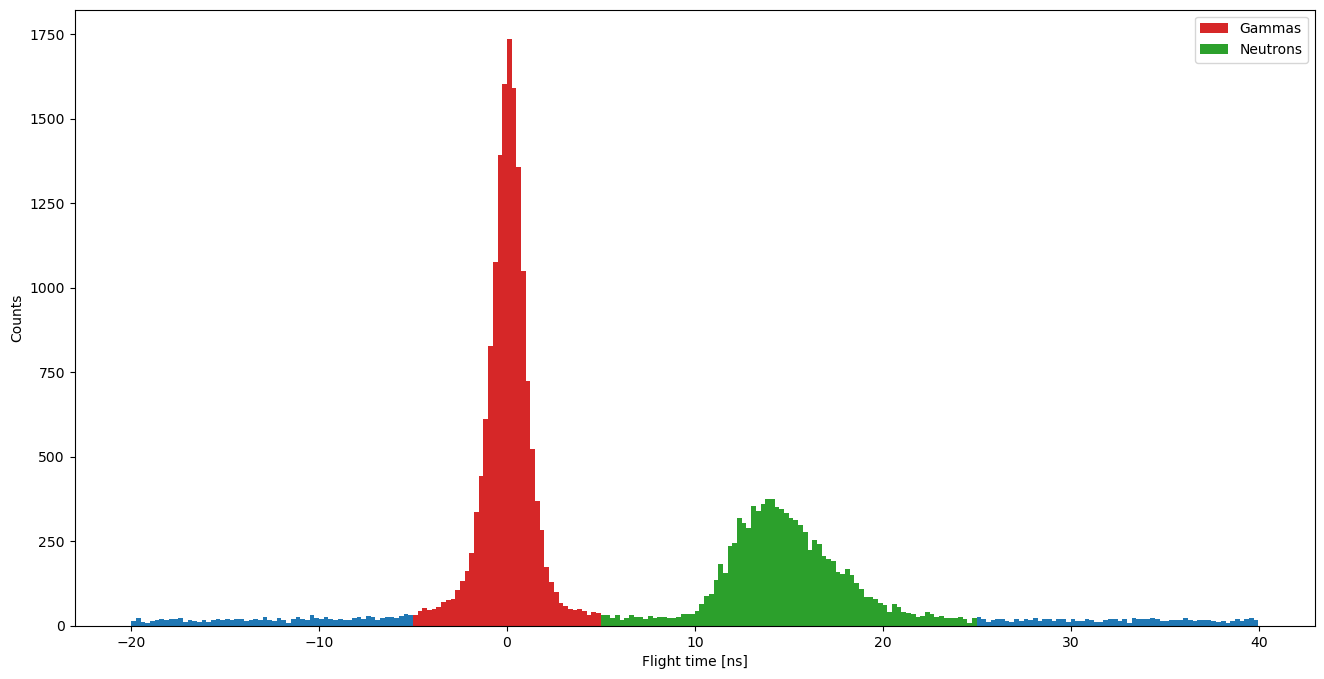

In [261]:
fig, ax  = plt.subplots(figsize=(16,8))
_, bin_edges, patches = ax.hist(times, bins=240)   # high resolution: 4 bins per nanosecond
bin_centres = (bin_edges[1:] + bin_edges[:-1]) / 2 
for i in range(len(patches)):
    if bin_centres[i] >= gamma_min_tof and bin_edges[i+1] <= gamma_max_tof:
        patches[i].set_facecolor('tab:red')
    elif bin_centres[i] >= neutron_min_tof and bin_edges[i+1] <= neutron_max_tof:
        patches[i].set_facecolor('tab:green')
patches[80].set_label('Gammas')
patches[120].set_label('Neutrons')
ax.set_xlabel('Flight time [ns]')
ax.set_ylabel('Counts')
ax.legend()
plt.show()

You now have two arrays with pulse shapes, one with only gammas (according to the flight times) and one with only neutrons (again, according to the flight times). Each array contains a large number of pulse shapes, each pulse consists of 512 detector readings.

Let's start preparing the data for the training of a neural network.

We scale the data so the pulse amplitudes ranges from 0 to 1. Before that, we flip the sign of the pulses, since we saw before that they are negative. Therefore, no signal yields a 0 value and the maximum signal is 1 in the scaled data.

In [262]:
# make a combined data set containing both pulse types
data = np.vstack((gammapulses, neutronpulses))
labels = np.zeros(len(data), dtype=int)
labels[:len(gammapulses)] = 1
# gammas are labelled as 1, and neutrons are labelled as 0

# normalize the data
data_scaled = -data
amplitude_max = np.max(data_scaled)
amplitude_min = np.min(data_scaled)
print(amplitude_max, amplitude_min)

data_scaled = (data_scaled - amplitude_min) / (amplitude_max - amplitude_min)

samples_per_pulse = len(data_scaled[0])

# in case you use a CNN architecture, we need to add an empty axis.
data_scaled = data_scaled[:,:, np.newaxis]

# before we split up the dataset into training, validation and test data set, we need to shuffle the events
# otherwise we end up having only one type of event in our validation and test data sets.
np.random.seed(1234)
shuffle_indices = np.arange(0, len(data_scaled), dtype=int)
np.random.shuffle(shuffle_indices)
data_scaled = data_scaled[shuffle_indices]
labels = labels[shuffle_indices]

2048.0 -5.0


In [263]:
len_train = data_scaled.shape[0] // 10 * 7
len_val = data_scaled.shape[0] // 10 * 3 // 2

data_train = data_scaled[:len_train]
data_val = data_scaled[len_train:len_train+len_val]
data_test = data_scaled[len_train+len_val:]

labels_train = labels[:len_train]
labels_val = labels[len_train:len_train+len_val]
labels_test = labels[len_train+len_val:]

print(labels_train.shape, labels_val.shape, labels_test.shape)

(18046,) (3867,) (3867,)


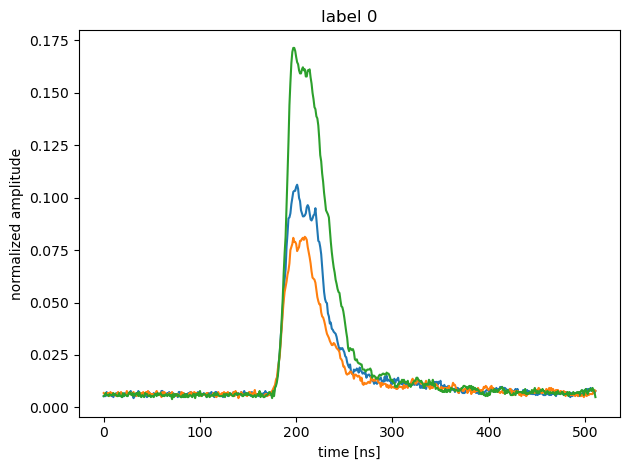

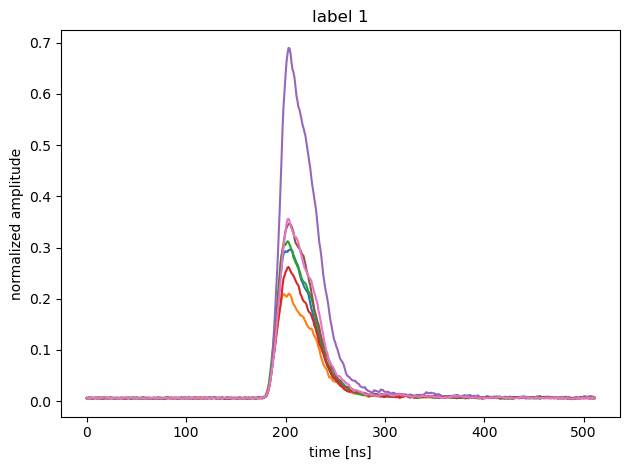

In [264]:
# plot a few events
fig, ax = plt.subplots(1, 1)
ax.set_title('label 0')
for i in range(10):
    if labels_train[i] == 0:
        ax.plot(data_train[i,:,0])
        ax.set_xlabel("time [ns]")
        ax.set_ylabel("normalized amplitude")
        fig.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1)
ax.set_title('label 1')
for i in range(10):
    if labels_train[i] == 1:
        ax.plot(data_train[i,:,0])
        ax.set_xlabel("time [ns]")
        ax.set_ylabel("normalized amplitude")
        fig.tight_layout()
plt.show()

In [265]:
# import os
# path = os.path.join('saved_models')
# if not os.path.exists(path):
#     os.makedirs(path)

### Small neural network

Now we can define the neural network and train it. We start with a simple fully connected network with one hidden layer of 32 neurons.

In [266]:
# first the usual imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Activation, Conv1D, Flatten, Dropout
from tensorflow.keras.layers import Dense, Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import AveragePooling2D, AveragePooling1D, Input, Flatten, MaxPooling1D, GlobalAveragePooling1D, GlobalMaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
from tensorflow.keras.utils import Sequence
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import CSVLogger
import pickle


model = Sequential()

# if you use a fully connected network (dense) you need to flatten the input data first. You can implement this
# as a network layer:
# model.add(Flatten(input_shape=(samples_per_pulse, 1)))

# if you use a convlutional layer first, you can directly use the input data
# model.add(Conv1D(, , padding=, activation=, input_shape=(samples_per_pulse, 1)))

model.add(Input(shape=(samples_per_pulse,)))
model.add(Flatten())
model.add(Dense(32, activation='relu',))
model.add(Dense(1, activation='sigmoid'))

print(model.summary())


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_20 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 32)             │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,449 (64.25 KB)

 Trainable params: 16,449 (64.25 KB)

 Non-trainable params: 0 (0.00 B)

None


In [267]:
model.compile(
    loss='binary_crossentropy', 
    optimizer='adam', # adam optimizer
    metrics=[keras.metrics.BinaryAccuracy(name='accuracy')]
)

In [268]:
results = model.fit(data_train, labels_train,
                    epochs = 20,
                    batch_size = 32,
                    validation_data = (data_val, labels_val),
                    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, verbose=1)]
                    )

Epoch 1/20
564/564 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7401 - loss: 0.5085 - val_accuracy: 0.8792 - val_loss: 0.3987
Epoch 2/20
564/564 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9293 - loss: 0.3240 - val_accuracy: 0.9449 - val_loss: 0.2781
Epoch 3/20
564/564 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9433 - loss: 0.2601 - val_accuracy: 0.9452 - val_loss: 0.2467
Epoch 4/20
564/564 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9437 - loss: 0.2429 - val_accuracy: 0.9452 - val_loss: 0.2371
Epoch 5/20
564/564 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9438 - loss: 0.2360 - val_accuracy: 0.9452 - val_loss: 0.2321
Epoch 6/20
564/564 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9439 - loss: 0.2326 - val_accuracy: 0.9452 - val_loss: 0.2289
Epoch 7/20
564/564 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9438 - loss: 0.2291 - val_accuracy: 0.9454 - val_loss: 0.2248
Epoch 8/20
564/564 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9440 - loss: 0.2249 - val_accuracy: 0.

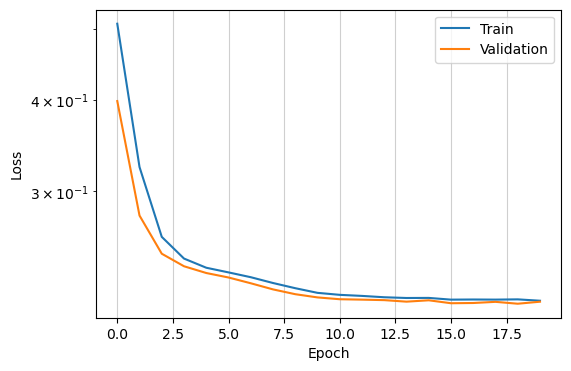

In [269]:
plt.figure(figsize=(6,4))
plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.ylabel('Loss')
plt.yscale("log")
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(alpha=0.6)
plt.show()

The generalization error is very small, so there is no overfitting.

In [270]:
pred_test = model.predict(data_test, batch_size=128)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


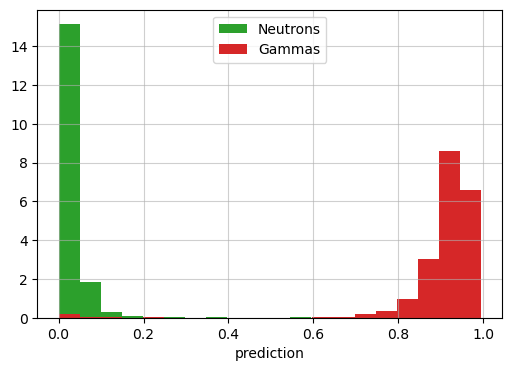

In [271]:
plt.figure(figsize=(6,4))
plt.hist(pred_test[labels_test == 0], bins=20, density=True, color='tab:green', label='Neutrons')
plt.hist(pred_test[labels_test == 1], bins=20, density=True, color='tab:red', label='Gammas')
plt.xlabel('prediction')
plt.grid(alpha=0.6)
plt.legend(loc='upper center')
plt.show()

Test accuracy = 0.9400


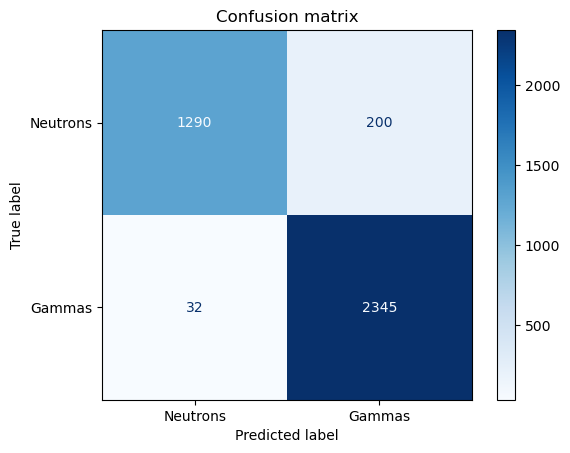

In [272]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred_labels_test = np.array((pred_test > 0.5), dtype=int).squeeze()

acc_test = np.mean(pred_labels_test == labels_test)
print(f'Test accuracy = {acc_test:.4f}')

cm = confusion_matrix(labels_test, pred_labels_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Neutrons', 'Gammas'] 
)

disp.plot(cmap=plt.cm.Blues, values_format='d')

plt.title('Confusion matrix')
plt.show()

We achieve an accuracy of 94.0% in the test dataset. Let us try to improve it.

### More complex network

We try now with a more complex model, a CNN with 2 convolutional layers and a fully connected hidden layer.

In [273]:
model = Sequential()

# if you use a fully connected network (dense) you need to flatten the input data first. You can implement this
# as a network layer:
# model.add(Flatten(input_shape=(samples_per_pulse, 1)))

# if you use a convlutional layer first, you can directly use the input data
# model.add(Conv1D(, , padding=, activation=, input_shape=(samples_per_pulse, 1)))

model.add(Input(shape=(samples_per_pulse, 1)))
model.add(Conv1D(16, 3, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(64, 3, padding='same', activation='relu'))
model.add(Flatten())
model.add(Dense(64, activation='relu'), Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

print(model.summary())

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 512, 16)        │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 256, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 256, 64)        │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_21 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │     1,048,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,051,905 (4.01 MB)

 Trainable params: 1,051,905 (4.01 MB)

 Non-trainable params: 0 (0.00 B)

None


In [274]:
model.compile(
    loss='binary_crossentropy', 
    optimizer='adam', # adam optimizer
    metrics=[keras.metrics.BinaryAccuracy(name='accuracy')]
)

results = model.fit(data_train, labels_train,
                    epochs = 20,
                    batch_size = 32,
                    validation_data = (data_val, labels_val),
                    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, verbose=1)]
                    )

Epoch 1/20
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8752 - loss: 0.3416 - val_accuracy: 0.9436 - val_loss: 0.2766
Epoch 2/20
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9423 - loss: 0.2438 - val_accuracy: 0.9457 - val_loss: 0.2328
Epoch 3/20
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9423 - loss: 0.2361 - val_accuracy: 0.9457 - val_loss: 0.2250
Epoch 4/20
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9436 - loss: 0.2296 - val_accuracy: 0.9444 - val_loss: 0.2215
Epoch 5/20
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9436 - loss: 0.2287 - val_accuracy: 0.9447 - val_loss: 0.2243
Epoch 6/20
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9431 - loss: 0.2298 - val_accuracy: 0.9444 - val_loss: 0.2194
Epoch 7/20
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9435 - loss: 0.2255 - val_accuracy: 0.9447 - val_loss: 0.2221
Epoch 8/20
564/564 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9434 - loss: 0.2230 - val_accuracy: 0.

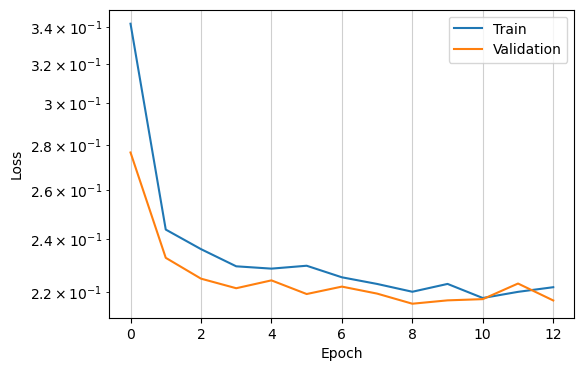

In [275]:
plt.figure(figsize=(6,4))
plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.ylabel('Loss')
plt.yscale("log")
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(alpha=0.6)
plt.show()

In [276]:
pred_test = model.predict(data_test, batch_size=128)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


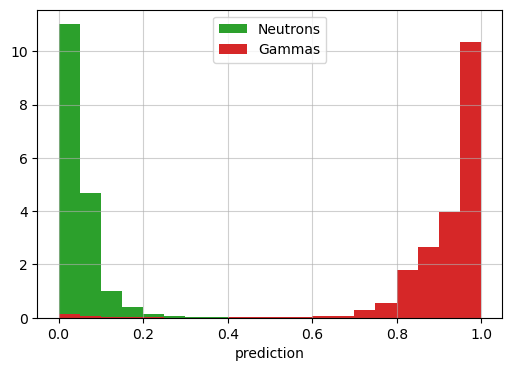

In [277]:
plt.figure(figsize=(6,4))
plt.hist(pred_test[labels_test == 0], bins=20, density=True, color='tab:green', label='Neutrons')
plt.hist(pred_test[labels_test == 1], bins=20, density=True, color='tab:red', label='Gammas')
plt.xlabel('prediction')
plt.grid(alpha=0.6)
plt.legend(loc='upper center')
plt.show()

Test accuracy = 0.9400


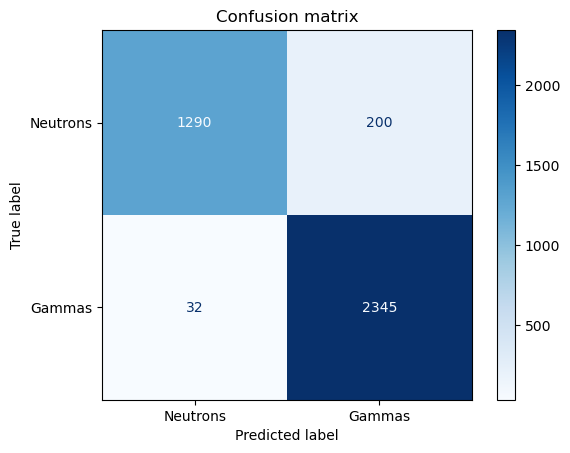

In [278]:
pred_labels_test = np.array((pred_test > 0.5), dtype=int).squeeze()

acc_test = np.mean(pred_labels_test == labels_test)
print(f'Test accuracy = {acc_test:.4f}')

cm = confusion_matrix(labels_test, pred_labels_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Neutrons', 'Gammas'] 
)

disp.plot(cmap=plt.cm.Blues, values_format='d')

plt.title('Confusion matrix')
plt.show()

The accuracy is again of 94.0%. We get no improvement regardless of the increment in complexity of the model. This shows that other factors are limiting the classification performance. More on it in the next section.

### Trying to improve the accuracy

One of the factors mentioned before can be the labelling. We set some limits to label the events as gammas and neutrons, but this is not a flawless procedure as we can mislabell some events (due to reflections, for example). Even if the network correctly understands the underlying characteristics of the event and determines the correct type, the label might be wrong leading to a lower accuracy.

We should use labels that are as reliable as possible for training. We can achieve this by restricting the cuts in the times-of-flight while keeping enough data to train.

In [279]:
gamma_min_tof = -2
gamma_max_tof = 2
neutron_min_tof = 11
neutron_max_tof = 18

gammadata2 = data_raw[(data_raw[:,1] >= gamma_min_tof) & (data_raw[:,1] <= gamma_max_tof)]
gammapulses2 = gammadata2[:,2:]
print('Gammas:  ', gammapulses2.shape)

neutrondata2 = data_raw[(data_raw[:,1] >= neutron_min_tof) & (data_raw[:,1] <= neutron_max_tof)]
neutronpulses2 = neutrondata2[:,2:]
print('Neutrons:', neutronpulses2.shape)

Gammas:   (14136, 512)
Neutrons: (7531, 512)


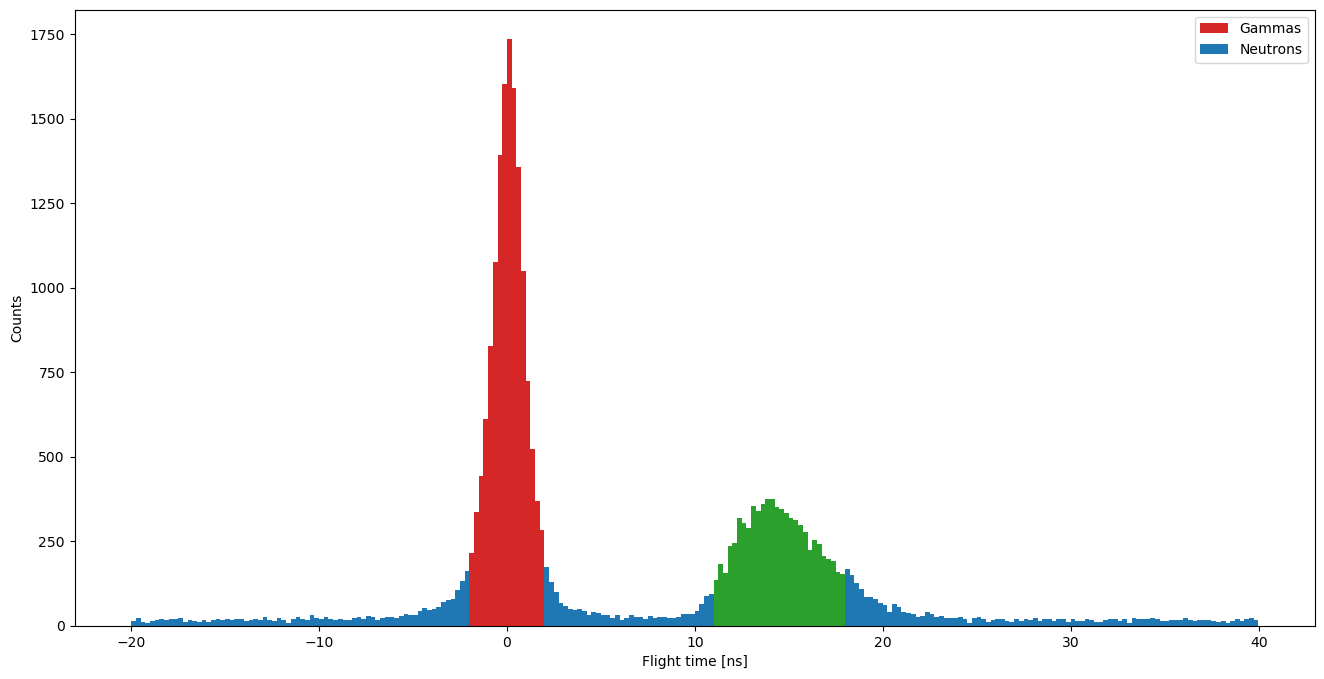

In [280]:
fig, ax  = plt.subplots(figsize=(16,8))
_, bin_edges, patches = ax.hist(times, bins=240)   # high resolution: 4 bins per nanosecond
bin_centres = (bin_edges[1:] + bin_edges[:-1]) / 2 
for i in range(len(patches)):
    if bin_centres[i] >= gamma_min_tof and bin_edges[i+1] <= gamma_max_tof:
        patches[i].set_facecolor('tab:red')
    elif bin_centres[i] >= neutron_min_tof and bin_edges[i+1] <= neutron_max_tof:
        patches[i].set_facecolor('tab:green')
patches[80].set_label('Gammas')
patches[120].set_label('Neutrons')
ax.set_xlabel('Flight time [ns]')
ax.set_ylabel('Counts')
ax.legend()
plt.show()

In [281]:
# make a combined data set containing both pulse types
data2 = np.vstack((gammapulses2, neutronpulses2))
labels2 = np.zeros(len(data2), dtype=int)
labels2[:len(gammapulses2)] = 1
# gammas are labelled as 1, and neutrons are labelled as 0

# normalize the data
data2_scaled = -data2
amplitude_max = np.max(data2_scaled)
amplitude_min = np.min(data2_scaled)
print(amplitude_max, amplitude_min)

data2_scaled = (data2_scaled - amplitude_min) / (amplitude_max - amplitude_min)

samples_per_pulse = len(data2_scaled[0])

# in case you use a CNN architecture, we need to add an empty axis.
data2_scaled = data2_scaled[:,:, np.newaxis]

# before we split up the dataset into training, validation and test data set, we need to shuffle the events
# otherwise we end up having only one type of event in our validation and test data sets.
np.random.seed(1234)
shuffle_indices = np.arange(0, len(data2_scaled), dtype=int)
np.random.shuffle(shuffle_indices)
data2_scaled = data2_scaled[shuffle_indices]
labels2 = labels2[shuffle_indices]

2048.0 -5.0


In [282]:
len_train = data2_scaled.shape[0] // 10 * 7
len_val = data2_scaled.shape[0] // 10 * 3 // 2

data2_train = data2_scaled[:len_train]
data2_val = data2_scaled[len_train:len_train+len_val]
data2_test = data2_scaled[len_train+len_val:]

labels2_train = labels2[:len_train]
labels2_val = labels2[len_train:len_train+len_val]
labels2_test = labels2[len_train+len_val:]

print(labels2_train.shape, labels2_val.shape, labels2_test.shape)

(15162,) (3249,) (3256,)


Since the model was not the problem, we use the simpler one.

In [283]:
model = Sequential()

model.add(Input(shape=(samples_per_pulse,)))
model.add(Flatten())
model.add(Dense(32, activation='relu',))
model.add(Dense(1, activation='sigmoid'))

print(model.summary())

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_22 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 32)             │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,449 (64.25 KB)

 Trainable params: 16,449 (64.25 KB)

 Non-trainable params: 0 (0.00 B)

None


In [284]:
model.compile(
    loss='binary_crossentropy', 
    optimizer='adam', # adam optimizer
    metrics=[keras.metrics.BinaryAccuracy(name='accuracy')]
)

results = model.fit(data2_train, labels2_train,
                    epochs = 20,
                    batch_size = 32,
                    validation_data = (data2_val, labels2_val),
                    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, verbose=1)]
                    )

Epoch 1/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7680 - loss: 0.4693 - val_accuracy: 0.9009 - val_loss: 0.3454
Epoch 2/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9691 - loss: 0.2439 - val_accuracy: 0.9726 - val_loss: 0.1940
Epoch 3/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9759 - loss: 0.1632 - val_accuracy: 0.9729 - val_loss: 0.1583
Epoch 4/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9761 - loss: 0.1445 - val_accuracy: 0.9729 - val_loss: 0.1500
Epoch 5/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9758 - loss: 0.1382 - val_accuracy: 0.9732 - val_loss: 0.1466
Epoch 6/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9757 - loss: 0.1357 - val_accuracy: 0.9729 - val_loss: 0.1490
Epoch 7/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9759 - loss: 0.1335 - val_accuracy: 0.9732 - val_loss: 0.1419
Epoch 8/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9761 - loss: 0.1287 - val_accuracy: 0.

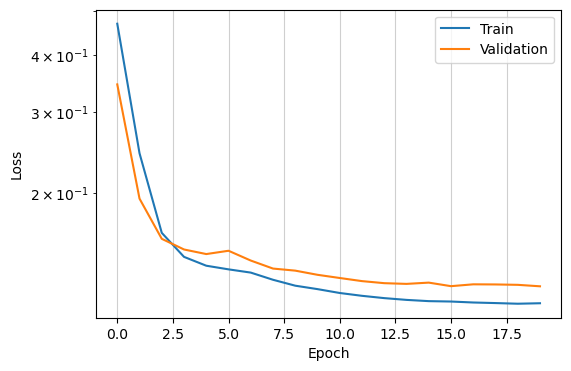

In [285]:
plt.figure(figsize=(6,4))
plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.ylabel('Loss')
plt.yscale("log")
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(alpha=0.6)
plt.show()

In [286]:
pred2_test = model.predict(data2_test, batch_size=128)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


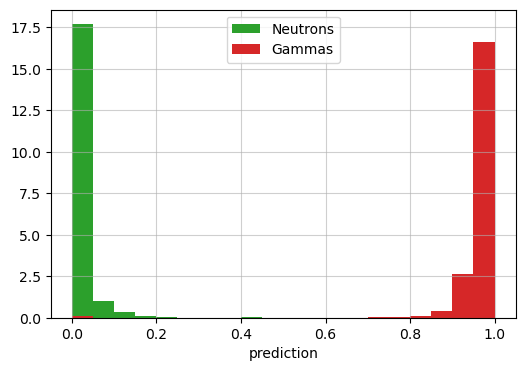

In [287]:
plt.figure(figsize=(6,4))
plt.hist(pred2_test[labels2_test == 0], bins=20, density=True, color='tab:green', label='Neutrons')
plt.hist(pred2_test[labels2_test == 1], bins=20, density=True, color='tab:red', label='Gammas')
plt.xlabel('prediction')
plt.grid(alpha=0.6)
plt.legend(loc='upper center')
plt.show()

Test accuracy = 0.9810


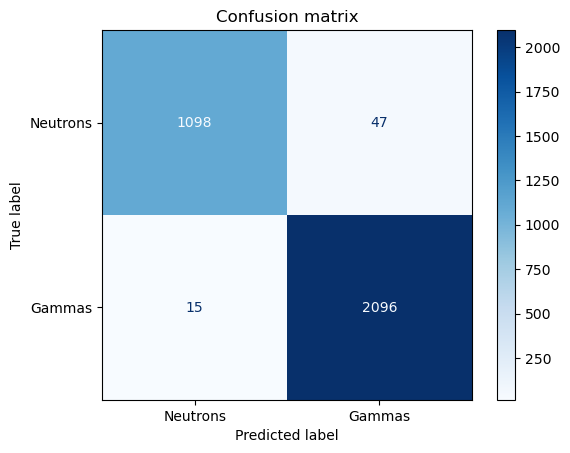

In [288]:
pred_labels2_test = np.array((pred2_test > 0.5), dtype=int).squeeze()

acc2_test = np.mean(pred_labels2_test == labels2_test)
print(f'Test accuracy = {acc2_test:.4f}')

cm = confusion_matrix(labels2_test, pred_labels2_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Neutrons', 'Gammas'] 
)

disp.plot(cmap=plt.cm.Blues, values_format='d')

plt.title('Confusion matrix')
plt.show()

We now get a test accuracy of 98.1%. The improvement is now noticeable. This confirms that the model was not the limiting factor, but the labelling before training.

### Accuracy discussion

The accuracy we got before can be a bit biased. As we discussed before, the test accuracy depends on the accuracy of the labelling. There is no easy way to know the latter. However, it is clear that the events closer to the peaks (in the time-of-flight histogram) have a larger probability of being correctly classified. This is why I think that the last accuracy we got is closer to the real one. We use the events that we can clearly label by hand to train, and then use the neural network to classify those that were not that clear from a time-of-flight point of view. The model relies on the pulse shape and not at all in the time-of-flight, so once it is able to distinguish the shapes, it can be as reliable for correctly labelled events as for the not that clear ones.

In short, I think an accuracy of around 98% is to be expected from the neural network.